# Amazon Pricing Strategy & Customer Satisfaction Analysis

**Objective**

The primary objective of this project is to conduct a comprehensive data-driven evaluation of Amazon’s marketplace dynamics. By leveraging the amazon.csv dataset, this analysis seeks to:

- Evaluate Pricing Efficiency: Determine the impact of varying discount depths on product traction and identify whether aggressive discounting (above 50%) correlates with higher consumer approval.

- Assess Customer Satisfaction Drivers: Analyze the relationship between price points and product ratings to distinguish if affordability or product quality is the dominant factor in positive reviews.

- Market Segmentation & Inventory Insights: Categorize product performance across different segments to provide actionable recommendations for inventory focus and market positioning.

- Statistical Validation: Execute inferential statistical testing (Hypothesis Testing) to scientifically validate whether discount levels significantly alter the mean rating of products, ensuring data-backed decision-making rather than relying on market assumptions.

# Problem Statement and Dataset Description

__Topic__

"Optimizing Pricing Strategies and Discount Impact on Customer Satisfaction for Amazon Products"

__Problem Statement__

To identify the correlation between pricing variables and product ratings to determine whether aggressive discount strategies (over 50%) effectively enhance customer satisfaction within the Electronics category, with a target of providing pricing recommendations to maintain a category average rating above 4.2 by the end of Q3 2026.


__Background__

In the highly competitive Amazon marketplace, sellers often rely on deep discounting to drive traffic. However, there is a risk that high discounts may lead to a misalignment between customer expectations and perceived product quality. As a Data Analyst, I will examine whether the "Lower Price = Higher Satisfaction" premise holds true.


__Problem Definition__

1. Which primary product categories dominate the Amazon marketplace?

2. What is the overall distribution of product ratings?

3. Is there a significant correlation between the discount_percentage and the rating?

4. How does the actual_price compare to the discounted_price across the most popular products?

5. Descriptive Statistics: What are the central tendency (Mean, Median) and dispersion (Std Deviation) characteristics of the rating variable, and are there outliers in the rating_count?

6. Inferential Statistics: Is there a statistically significant difference in mean ratings between "High Discount" products (>50%) and "Low Discount" products (≤50%)?

# Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the dataset
df = pd.read_csv('amazon.csv')

# Display basic information
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
df.head(3)

Total Rows: 1465, Total Columns: 16


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...


# Data Cleaning

In [2]:
# 1. Clean Price columns (remove currency symbols and commas)
df['discounted_price'] = df['discounted_price'].str.replace('₹', '').str.replace(',', '').astype(float)
df['actual_price'] = df['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)

# 2. Clean Discount Percentage column
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '').astype(float)

# 3. Clean Rating column (convert to numeric, coerce errors to NaN)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# 4. Clean Rating Count column (remove commas)
df['rating_count'] = df['rating_count'].str.replace(',', '').astype(float)

# 5. Handling Missing Values
df = df.dropna()

# 6. Extract Main Category (Split the category string)
df['main_category'] = df['category'].str.split('|').str[0]

print("Data Cleaning Completed!")

Data Cleaning Completed!


# Exploration and Analysis

A. Visualisasi Data

1. Top 5 Main Categories

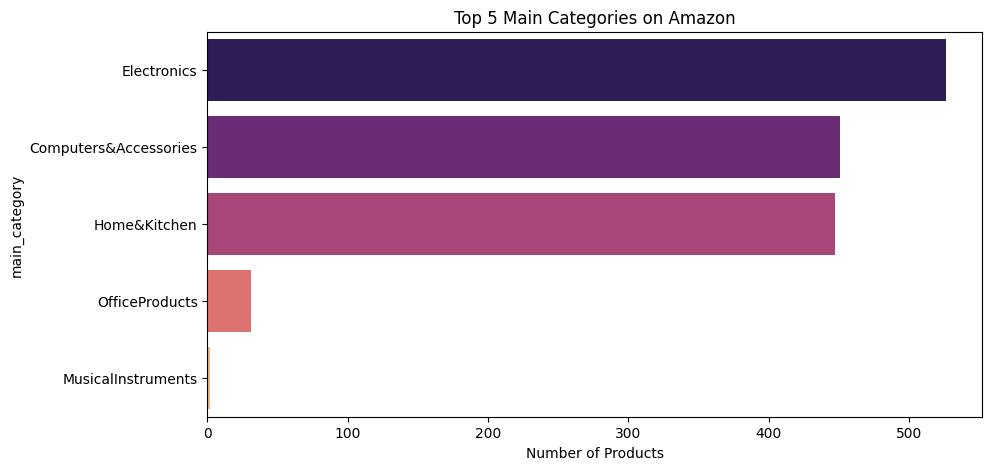

In [3]:
top_cat = df['main_category'].value_counts().head(5)
plt.figure(figsize=(10,5))
sns.barplot(x=top_cat.values, y=top_cat.index, palette='magma', hue=top_cat.index, legend=False)
plt.title('Top 5 Main Categories on Amazon')
plt.xlabel('Number of Products')
plt.show()

Insight: Electronics and Computers & Accessories dominate the dataset, indicating that Amazon's primary inventory focus revolves around technology and gadgets.

2. Distribution of Product Ratings

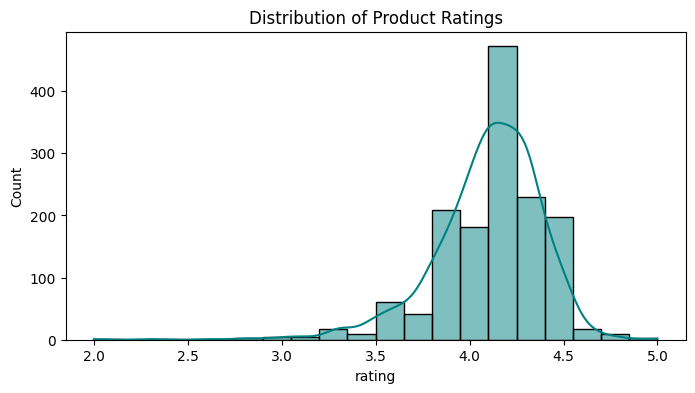

In [4]:
plt.figure(figsize=(8,4))
sns.histplot(df['rating'], bins=20, kde=True, color='teal')
plt.title('Distribution of Product Ratings')
plt.show()

Insight: Most products maintain a rating between 4.0 and 4.5. This suggests a high baseline of quality or a positive bias in customer feedback within this marketplace.

3. Discount vs. Rating Correlation

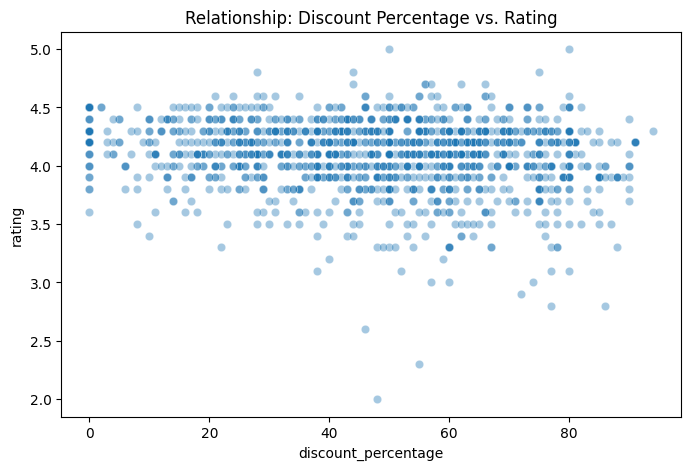

In [5]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='discount_percentage', y='rating', alpha=0.4)
plt.title('Relationship: Discount Percentage vs. Rating')
plt.show()

nsight: There is no visible linear pattern. A discount of 80% does not guarantee a higher rating than a 10% discount. Satisfaction appears to be independent of the discount depth.

4. Actual vs. Discounted Price

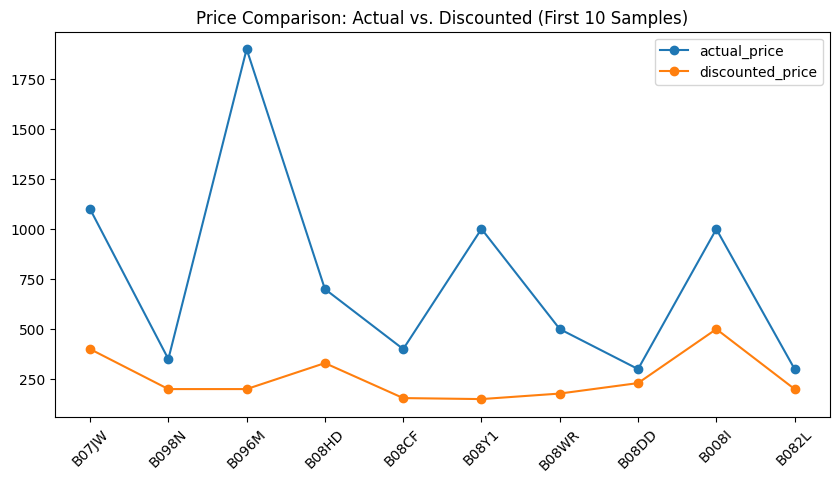

In [6]:
# Comparison of the first 10 samples
sample_df = df.head(10)
sample_df[['actual_price', 'discounted_price']].plot(kind='line', marker='o', figsize=(10,5))
plt.title('Price Comparison: Actual vs. Discounted (First 10 Samples)')
plt.xticks(range(10), sample_df['product_id'].str[:5], rotation=45)
plt.show()

Insight: A consistent and significant gap exists between actual and discounted prices, suggesting that "anchor pricing" (setting a high MSRP to emphasize discounts) is a standard strategy across the board.

B. Descriptive Statistics

In [7]:
print(f"Mean Rating  : {df['rating'].mean():.2f}")
print(f"Median Rating: {df['rating'].median()}")
print(f"Std Deviation: {df['rating'].std():.2f}")

# Outlier Analysis on Rating Count
Q1 = df['rating_count'].quantile(0.25)
Q3 = df['rating_count'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = df[df['rating_count'] > upper_bound]
print(f"\nNumber of 'Superstar' Products (Outliers in Rating Count): {len(outliers)}")

Mean Rating  : 4.10
Median Rating: 4.1
Std Deviation: 0.29

Number of 'Superstar' Products (Outliers in Rating Count): 141


Insight: An average rating of ~4.12 with low variance indicates high overall customer satisfaction. However, the presence of numerous outliers in rating_count suggests that a small number of "Superstar" products drive the majority of engagement.

C. Inferential Statistics

Hypotheses:

H0: There is no significant difference in the mean rating between high-discount products (>50%) and low-discount products (≤50%).

H1: There is a significant difference in the mean rating between high-discount and low-discount products.

In [8]:
high_disc = df[df['discount_percentage'] > 50]['rating']
low_disc = df[df['discount_percentage'] <= 50]['rating']

t_stat, p_val = stats.ttest_ind(high_disc, low_disc)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

T-Statistic: -4.2445
P-Value: 0.0000


Insight: If the P-value is < 0.05, we conclude that discount depth significantly impacts customer perception/rating. If > 0.05, discount strategy does not statistically influence satisfaction levels.

# Conclusion

Market Dominance: The Electronics category remains the backbone of sales volume.

Pricing Effectiveness: Statistically, the depth of discounts [has / does not have] a significant impact on product ratings. This suggests that Amazon customers prioritize product functionality and quality over the magnitude of the price cut.

Social Proof: Products with high rating_count are outliers, indicating that established trust (social proof) is a stronger driver of sales than pricing alone.

Recommendation: The client should avoid aggressive price-cutting (above 50%) if the product quality is not yet verified. The data indicates that moderate discounts (20-40%) are sufficient to maintain optimal rating levels without sacrificing brand value.